# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [29]:
# Install Package 
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [30]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head()
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

#

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),...,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,...,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17-Oct-24


In [7]:
data.shape

(3702, 44)

In [8]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [25]:
# Count the number of N/A values in each column
number_of_columns = data.shape[1]
for i in range(number_of_columns):
    col_name = data.columns[i]
    count = data[col_name].isna().sum()
    print(f"The number of NA values in column '{col_name}' is {count}")

The number of NA values in column 'Manufacturer' is 0
The number of NA values in column 'Model' is 0
The number of NA values in column 'Description' is 0
The number of NA values in column 'Transmission' is 558
The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 2
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 19
The number of NA values in column 'Engine Power (Kw)' is 8
The number of NA values in column 'Electric energy consumption Miles/kWh' is 883
The number of NA values in column 'wh/km' is 2516
The number of NA values in column 'Maximum range (Km)' is 2375
The number of NA values in column 'Maximum range (Miles)' is 2702
The number of NA values in column 'Euro Standard' is 0
The number of NA values in column 'Diesel VED Supplement' is 0
The number of NA values in column 'Testing Scheme' is 0
The number of NA

In [26]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


In [27]:
# Define fuel type categories for each group
electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric", "Electricity / Diesel"
]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
data_electric = data[data["Fuel Type"].isin(electric_types)]
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Electric cars: 750 rows
Hybrid cars: 1702 rows
Fuel cars: 1250 rows
Original data: 3702 rows 


In [24]:
# Examine splitted datasets
print(data_fuel.head())
print("\n")
print(data_electric.head())
print("\n")
print(data_hybrid.head())

  Manufacturer     Model                                      Description  \
4       ABARTH  595 MY23              Turismo 1.4 Tjet 165 hp Manual (VL)   
5       ABARTH  595 MY23              Turismo 1.4 Tjet 165 hp Manual (VH)   
6       ABARTH  595 MY23  Turismo 1.4 Tjet 165 hp Manual Convertible (VL)   
7       ABARTH  595 MY23  Turismo 1.4 Tjet 165 hp Manual Convertible (VH)   
8       ABARTH  695 MY22         Turismo 1.4 Tjet 180 hp Manual (VH only)   

  Transmission Manual or Automatic  Engine Capacity Fuel Type  \
4           M5              Manual           1368.0    Petrol   
5           M5              Manual           1368.0    Petrol   
6           M5              Manual           1368.0    Petrol   
7           M5              Manual           1368.0    Petrol   
8           M5              Manual           1368.0    Petrol   

                         Powertrain  Engine Power (PS)  Engine Power (Kw)  \
4  Internal Combustion Engine (ICE)              165.0              1

### Statistical Analysis

In [31]:
# Review Mean, Min, Max, SD of data
data.describe()

,Engine Capacity,Engine Power (PS),Engine Power (Kw),Electric energy consumption Miles/kWh,wh/km,Maximum range (Km),Maximum range (Miles),WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,...,Electric Range City Miles,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A)
count,3700.000000,3683.000000,3694.000000,2819.000000,1186.000000,1327.000000,1000.000000,3702.000000,3702.000000,3702.000000,...,997.000000,1317.000000,3430.000000,2805.000000,3060.000000,1084.000000,1454.000000,1865.000000,1864.000000,3702.000000
mean,1457.020000,202.254141,160.312398,1.896595,171.558179,270.663150,215.574000,29.834414,36.915073,39.302728,...,281.998997,355.225513,203.393003,18.046346,14.306536,16.828413,0.279684,61.390885,61.470494,63.854376
std,1039.860432,127.951896,140.140297,3.913432,42.727697,217.607324,122.291667,21.940253,24.854016,25.423989,...,158.354937,283.536294,182.095444,13.217321,12.533870,22.736478,0.403570,20.181420,20.238253,15.280512
min,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,999.000000,129.000000,95.000000,0.000000,156.000000,57.000000,102.750000,0.000000,0.000000,0.000000,...,69.000000,64.000000,40.000000,11.000000,6.000000,0.000000,0.040000,60.000000,60.000000,66.000000
50%,1490.000000,160.000000,120.000000,0.000000,170.000000,333.000000,251.000000,34.400000,44.800000,50.400000,...,334.000000,458.000000,165.000000,17.000000,12.000000,0.000000,0.125000,60.000000,60.000000,67.000000
75%,1993.000000,244.000000,184.000000,3.500000,188.000000,453.500000,296.000000,42.200000,53.300000,57.600000,...,400.000000,602.000000,311.000000,24.000000,21.000000,29.000000,0.370000,60.000000,60.000000,68.000000
max,6749.000000,1267.000000,1200.000000,38.400000,303.000000,820.000000,510.000000,100.900000,97.400000,80.700000,...,573.000000,922.000000,918.000000,156.000000,216.000000,124.000000,3.440000,179.000000,179.000000,77.000000


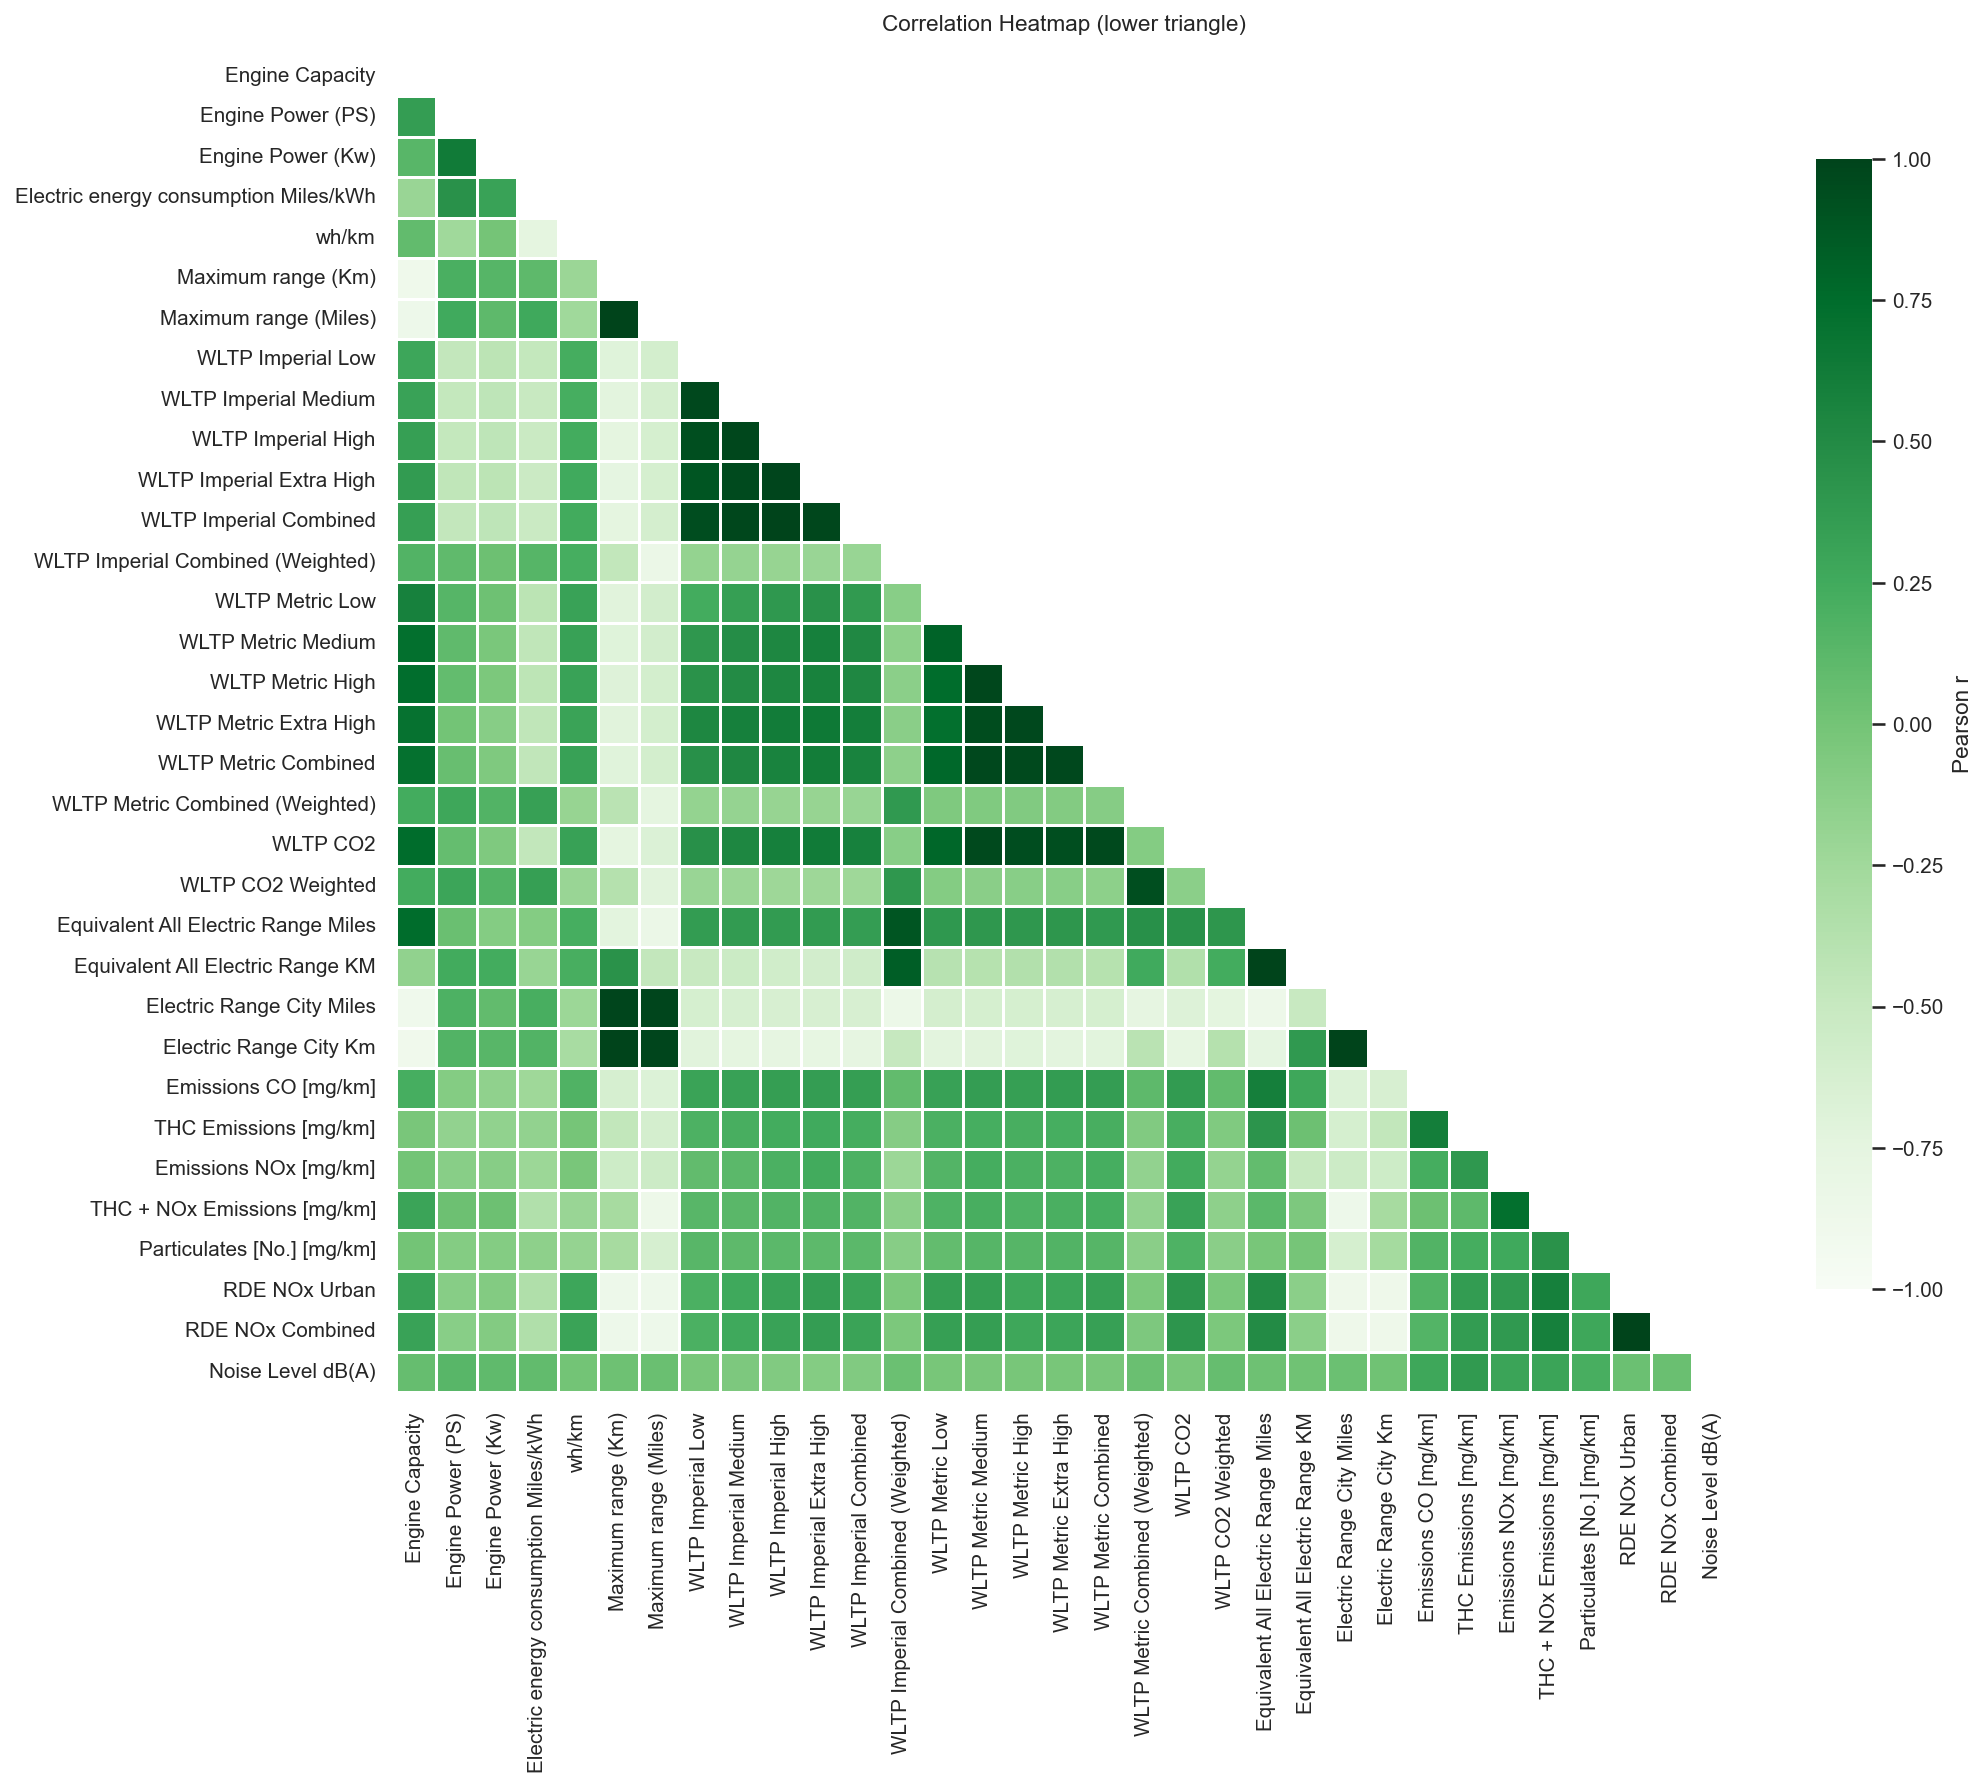

In [34]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", pad=12)
plt.tight_layout()
plt.show()

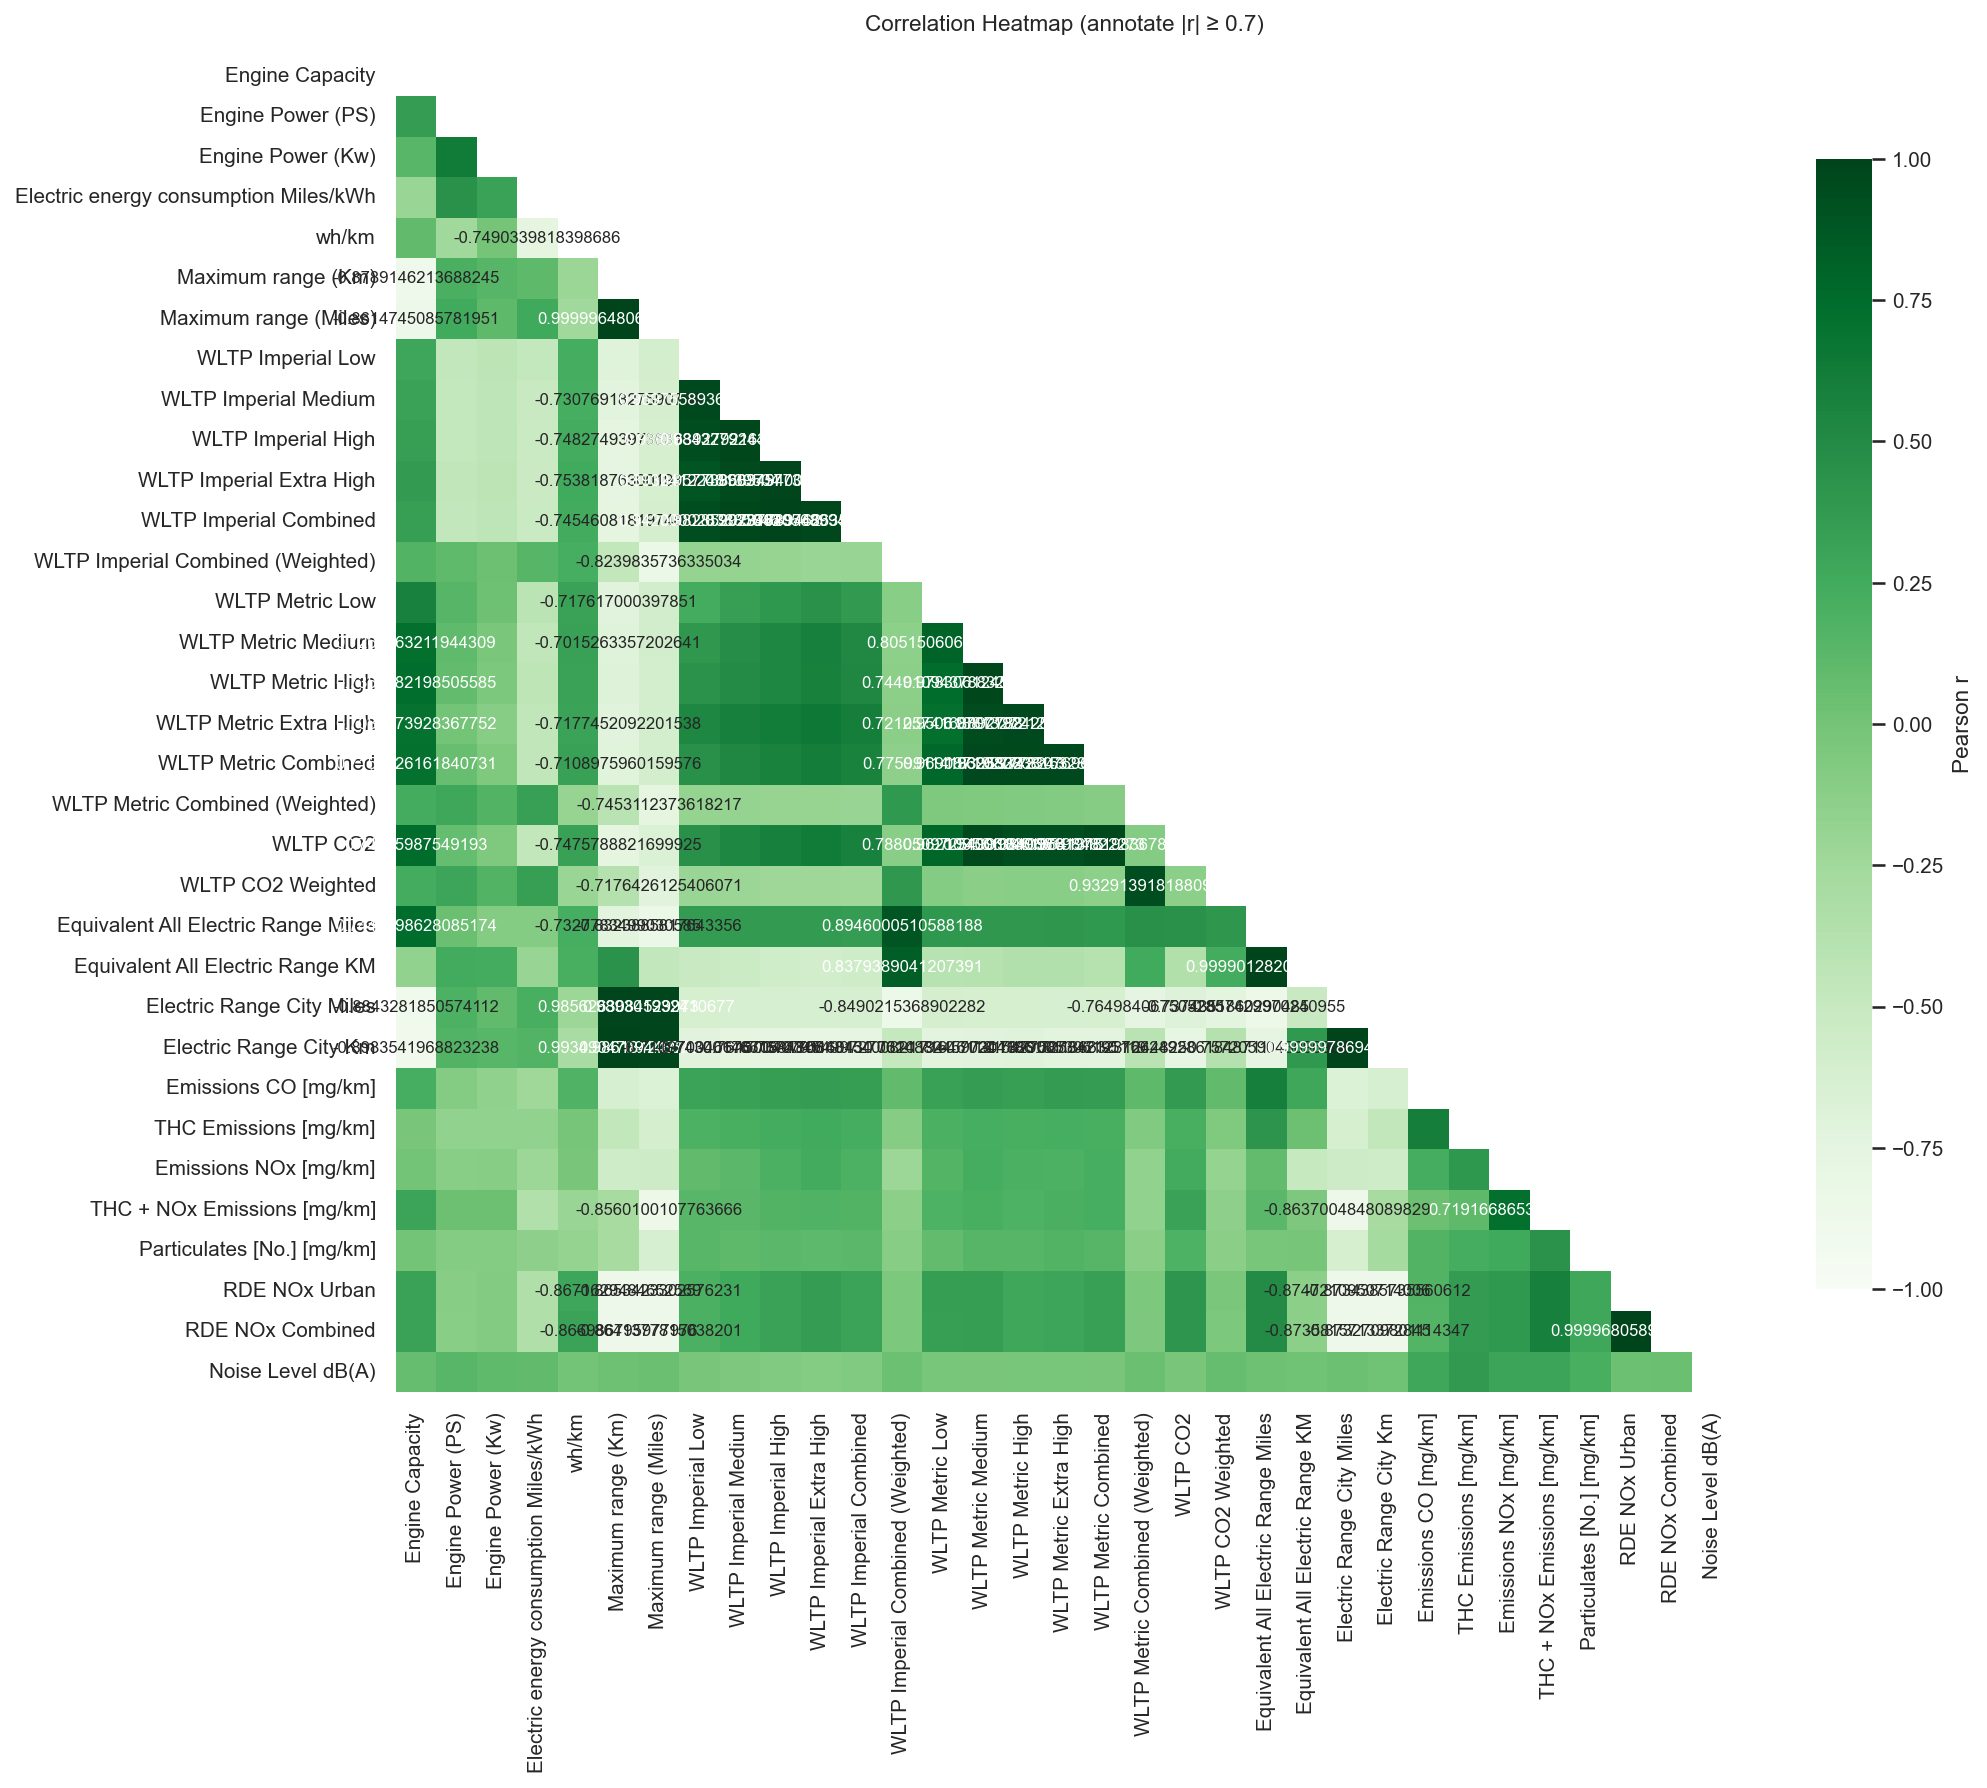

In [35]:
thr = 0.7
corr_annot = corr.where(mask==0)                    # lower tri
labels = corr_annot.copy().astype(str)
labels[(corr_annot.abs() < thr) | corr_annot.isna()] = ""  # blank weak cells

plt.figure(figsize=(14, 12), dpi=150)
sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=labels, fmt="", annot_kws={"fontsize":8}, square=True
)
plt.title(f"Correlation Heatmap (annotate |r| ≥ {thr})", pad=12)
plt.tight_layout()
plt.show()


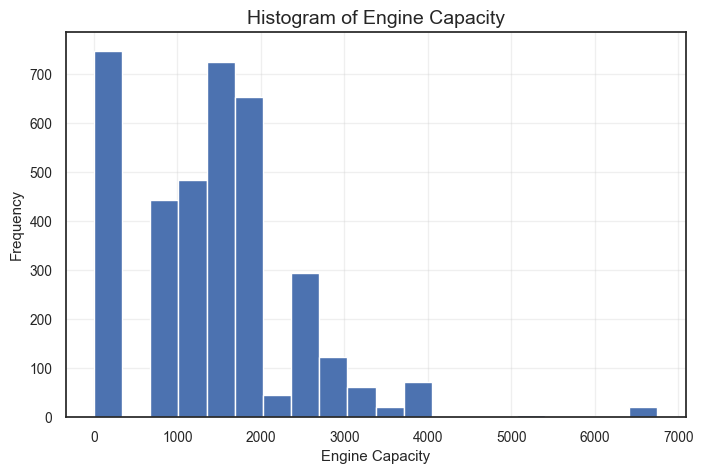

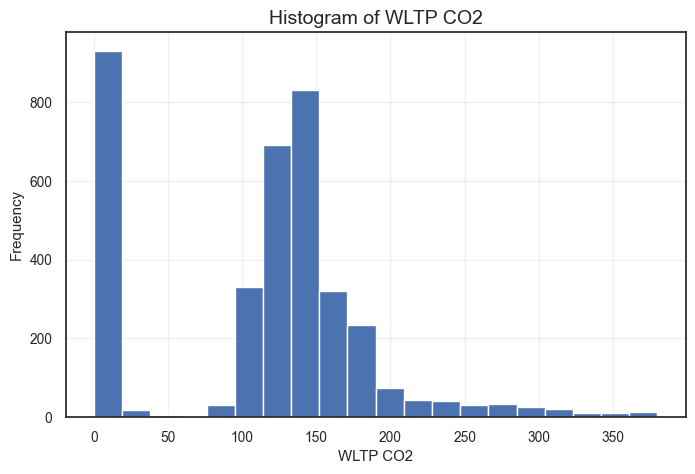

In [41]:
# -- Plots a histogram for a numeric variable from the dataset, 
## arguments are the column name (string) and the dataframe.
def plot_numeric_histogram(column_name, df):
    
    if column_name not in df.columns:
        print(f" Column '{column_name}' is not found in dataset.")
        return
    
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f" Column '{column_name}' is not numeric. Please select a numeric variable.")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(df[column_name].dropna(), bins=20)
    plt.title(f"Histogram of {column_name}", fontsize=14)
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

# --------------------------------------------
# Example usage
# --------------------------------------------
plot_numeric_histogram("Engine Capacity", data)
plot_numeric_histogram("WLTP CO2", data)

 Column 'Manufacturer' is not numeric. Please select a numeric variable.
 Column 'Model' is not numeric. Please select a numeric variable.
 Column 'Description' is not numeric. Please select a numeric variable.
 Column 'Transmission' is not numeric. Please select a numeric variable.
 Column 'Manual or Automatic' is not numeric. Please select a numeric variable.


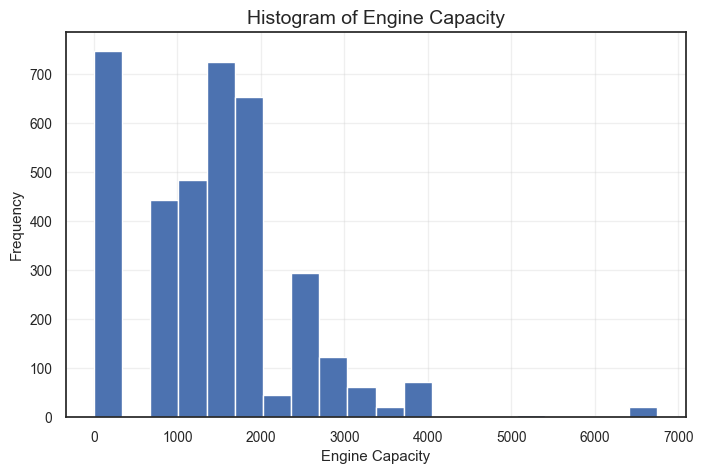

 Column 'Fuel Type' is not numeric. Please select a numeric variable.
 Column 'Powertrain' is not numeric. Please select a numeric variable.


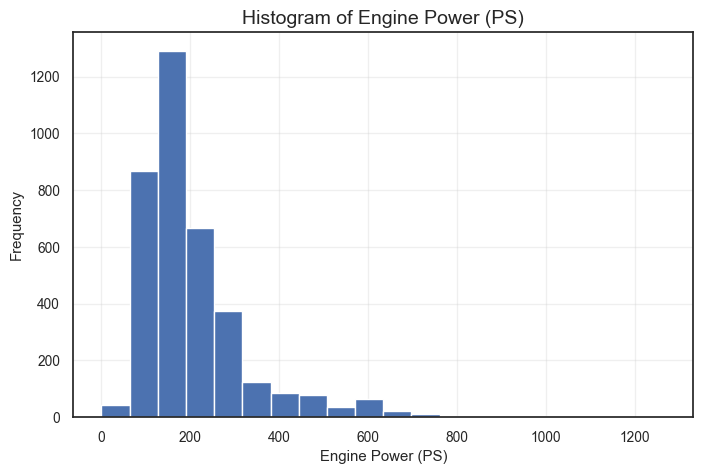

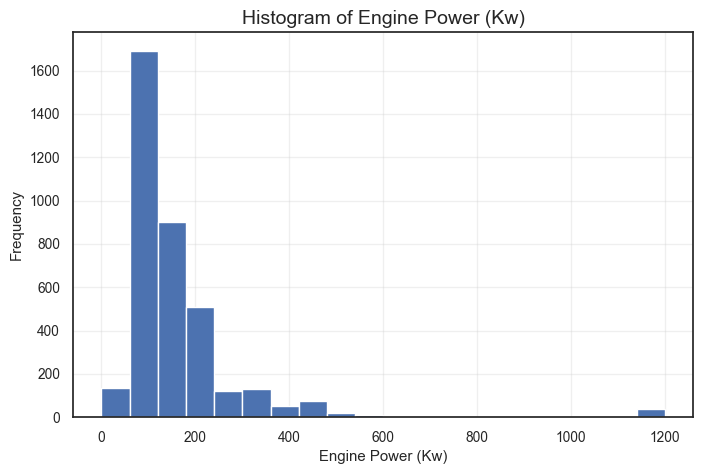

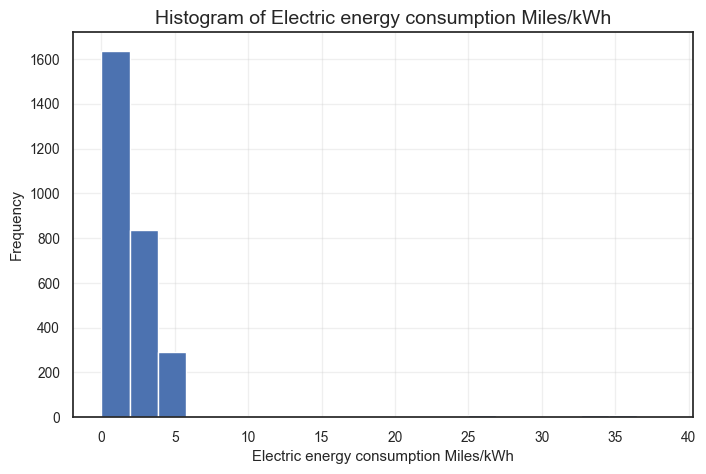

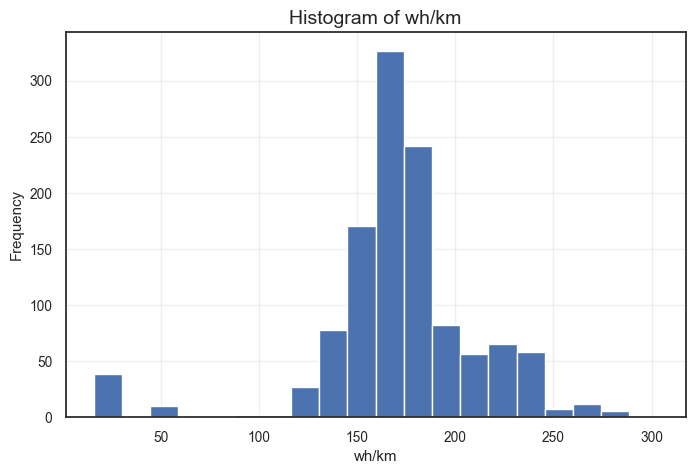

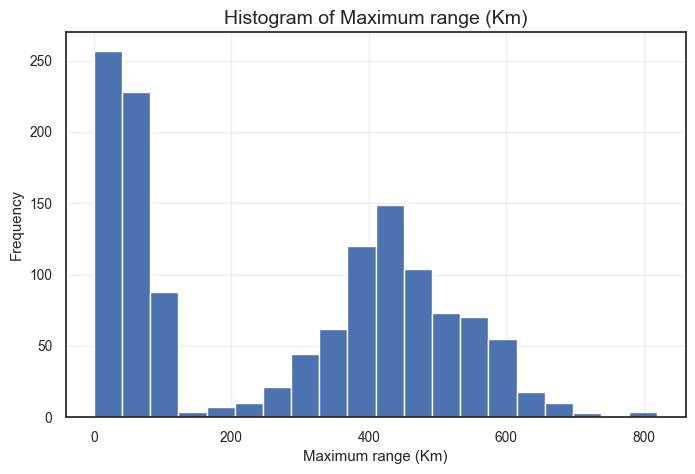

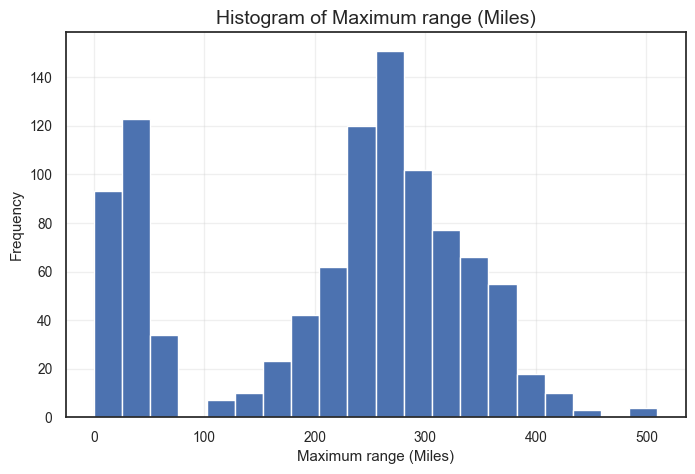

 Column 'Euro Standard' is not numeric. Please select a numeric variable.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

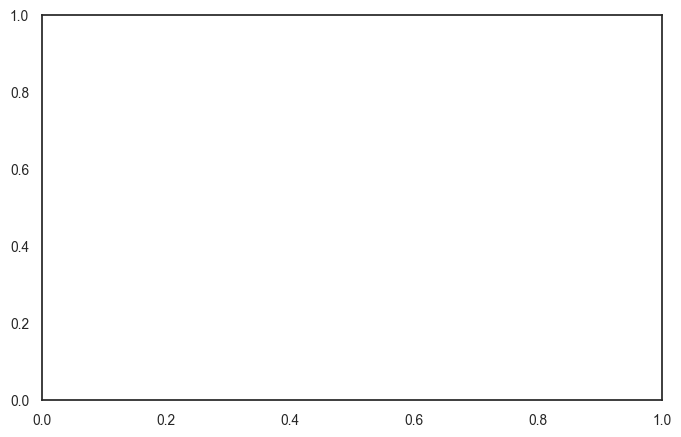

In [42]:
#-- My idea: automate histogram plotting for all numeric columns
for i in range(number_of_columns):
    col_name = data.columns[i]
    plot_numeric_histogram(col_name, data)

Here are some steps for statistical analysis with your dataset:

1. **Descriptive Statistics**:  
    Use `data.describe()` to get mean, median, std, min, max, and quartiles for numerical columns.

2. **Missing Data Analysis**:  
    Check missing values with `data.isnull().sum()`. Decide on imputation or removal.

3. **Correlation Analysis**:  
    Use `data.corr()` to find relationships between variables. Visualize with a heatmap (already done).

4. **Distribution Analysis**:  
    Plot histograms or boxplots for key variables to check their distributions and outliers.

5. **Group Comparisons**:  
    Use `groupby()` to compare statistics across categories (e.g., Fuel Type, Powertrain).

6. **Feature Selection**:  
    Identify highly correlated features (see your `top15_df`) and consider removing redundant ones.

7. **Regression/Classification Prep**:  
    Identify your target variable. If it's continuous, use regression; if categorical, use classification.

8. **Validation Strategy**:  
    Plan for cross-validation (e.g., KFold) to assess model performance.

9. **Data Visualization**:  
    Use scatter plots, pairplots, or bar charts to visualize relationships and trends.

Let me know which step you want to explore further or need code for.

### Data Visualisation

Text(0.5, 1.0, 'Average CO2 Emissions by Fuel Type')

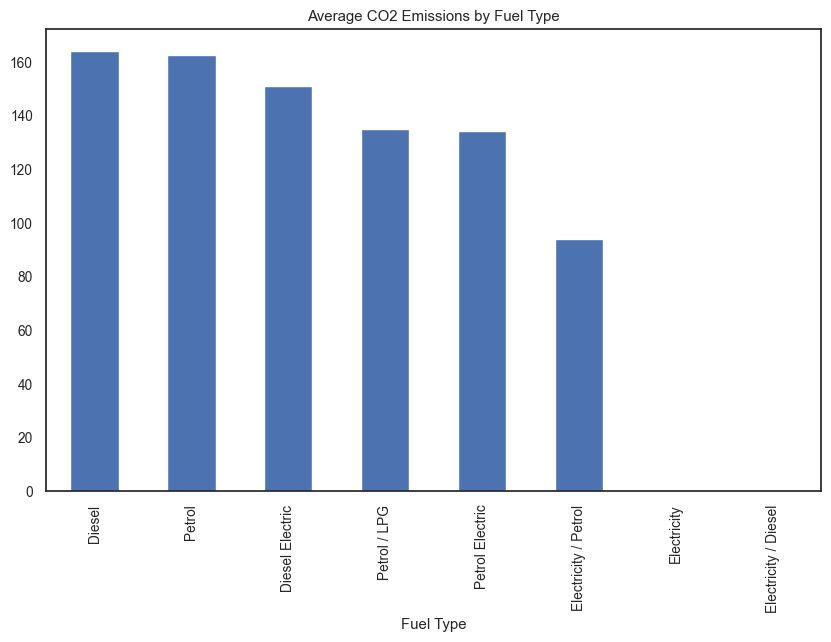

In [53]:
data.groupby("Fuel Type")["WLTP CO2"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,6))
plt.title("Average CO2 Emissions by Fuel Type")

### The validation of datasets

*Fuel car data*


10-fold CV MSE scores: [67.24603241091525, 33.09040844872687, 80791.07994643973, 73.80745526060615, 67.4558263466672, 143.927233335912, 54.779379298967825, 101.50567729580402, 1860.5364599793547, 30.152910794794476]
Mean MSE: 8322.358132961148


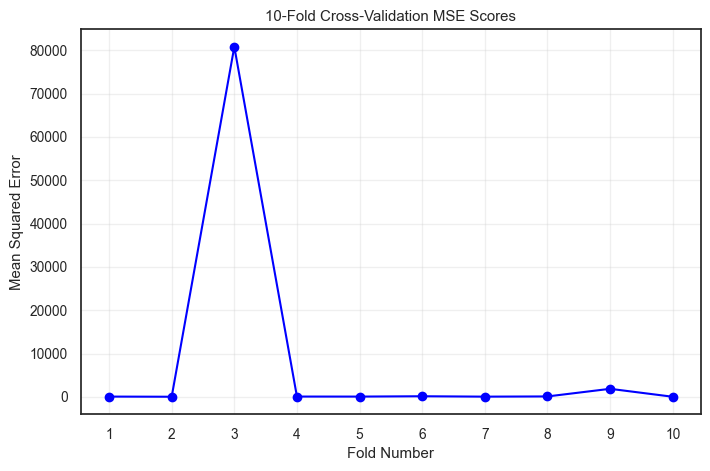

In [52]:
# Prepare X and y
X = data_fuel.drop(columns=["WLTP CO2"])
y = data_fuel["WLTP CO2"]

# Remove categorical variables from X for linear regression
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
X = X.drop(columns=categorical_cols)

# Fill missing values in X with column means (numeric columns only)
X = X.fillna(X.mean(numeric_only=True))
# If any non-numeric columns remain with NaN after encoding, fill with a placeholder
X = X.fillna(0)

# Split into train (70%), temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split temp into test (20%) and validation (10%)
test_size = 2/3  # 20% out of 30%
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=test_size, random_state=42)

# 10-fold cross-validation on training set
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    #Calculate MSE on the validation fold
    y_pred = model.predict(X_cv)
    mse = mean_squared_error(y_cv, y_pred)
    mse_scores.append(mse)

print("10-fold CV MSE scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-', color='blue')
plt.title('10-Fold Cross-Validation MSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('Mean Squared Error')
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

*Electric car data*

10-fold CV MSE scores: [9.609984040760219, 5.217872197804605, 3.3972700887290324, 233.02729333288576, 7.727858614954663, 167.3009154930637, 160.293998412919, 3.249254419293389, 10.24872941544673, 3.9686354566113886]
Mean MSE: 60.40418114724686


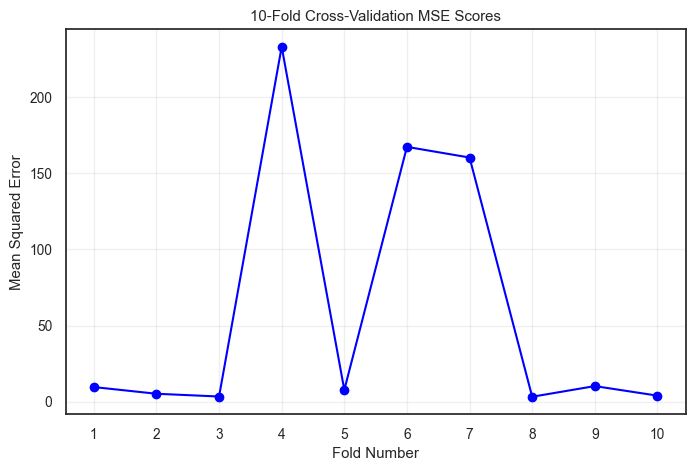

In [59]:
# Prepare X and y
y = data_electric["Electric Range City Km"] #pick Electric Range City Km as a target variable for electric cars.
X = data_electric.drop(columns=["Electric Range City Km"]) 

# Remove categorical variables from X for linear regression
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
X = X.drop(columns=categorical_cols)

# Fill missing values in X with column means (numeric columns only)
X = X.fillna(X.mean(numeric_only=True))
# If any non-numeric columns remain with NaN after encoding, fill with a placeholder
X = X.fillna(0)

# Split into train (70%), temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42)

# Split temp into test (20%) and validation (10%)
test_size = 2/3  # 20% out of 30%
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=test_size, 
                                                random_state=42)

# 10-fold cross-validation on training set
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    
    #Calculate MSE on the validation fold
    y_pred = model.predict(X_cv)
    mse = mean_squared_error(y_cv, y_pred)
    mse_scores.append(mse)

print("10-fold CV MSE scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-', color='blue')
plt.title('10-Fold Cross-Validation MSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('Mean Squared Error')
plt.grid(alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

In [ ]:
(Please ignore this part, I put here for reference to my work)
Here are some steps for statistical analysis with your dataset:
1. **Descriptive Statistics**:  
    Use `data.describe()` to get mean, median, std, min, max, and quartiles for numerical columns.

2. **Missing Data Analysis**:  
    Check missing values with `data.isnull().sum()`. Decide on imputation or removal.

3. **Correlation Analysis**:  
    Use `data.corr()` to find relationships between variables. Visualize with a heatmap (already done).

4. **Distribution Analysis**:  
    Plot histograms or boxplots for key variables to check their distributions and outliers.

5. **Group Comparisons**:  
    Use `groupby()` to compare statistics across categories (e.g., Fuel Type, Powertrain).

6. **Feature Selection**:  
    Identify highly correlated features (see your `top15_df`) and consider removing redundant ones.

7. **Regression/Classification Prep**:  
    Identify your target variable. If it's continuous, use regression; if categorical, use classification.

8. **Validation Strategy**:  
    Plan for cross-validation (e.g., KFold) to assess model performance.

9. **Data Visualization**:  
    Use scatter plots, pairplots, or bar charts to visualize relationships and trends.

Let me know which step you want to explore further or need code for.

SyntaxError: unterminated string literal (detected at line 22) (3425279247.py, line 22)